## Pipeline 2: Bacteria in high resolution

This is a representative image from the round2/4000x dataset, chosen to show several categories of detection (ball, rod, debris, dividing-ball).

## Step 0: Load Image

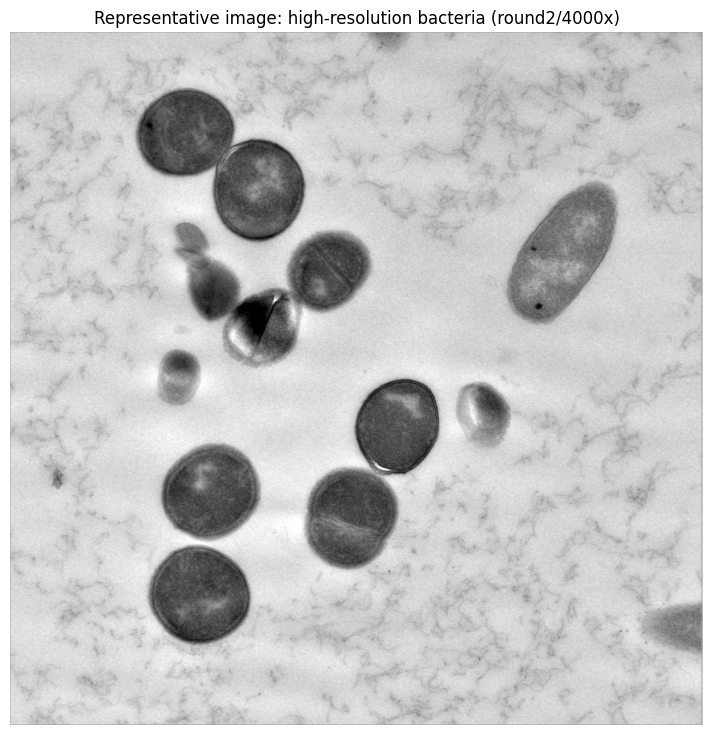

In [1]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt

img = tifffile.imread("example_high_res_4000x.tif")
gray = img.mean(axis=-1).astype(np.uint8)

plt.figure(figsize=(9, 9))
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("Representative image: high-resolution bacteria (round2/4000x)")
plt.axis("off")
plt.show()

## Step 1: Segmentation via CPSAM. 
This is the most intensive step computationally. The expected labels have been also provided. Uncomment the cell below to execture cpsam. The notebook can function without this cell

In [ ]:
# Uncomment to run CellPose-SAM live (needs a GPU for reasonable runtime -- see
# timing note below once measured). diameter=200 matches the deployed pipeline's
# GUI default for these images (cells are much larger here than in the
# low-resolution pipeline, ~300-1000px vs ~30px, so the parameter differs from
# Pipeline 1). By default this notebook uses the precomputed reference output
# loaded in the next cell (the same file the rest of this project's analysis
# was built on).

# from cellpose import models
#
# model = models.CellposeModel(gpu=True)
# masks_live, flows, styles = model.eval(
#     img, diameter=200, flow_threshold=0.4, cellprob_threshold=-1.0,
# )
# print(f"{masks_live.max()} cells detected")
# np.save("example_high_res_labels.npy", masks_live)

This is what you should get (the actual detection used throughout this project for this image, for reference if running on a slow/CPU-only machine):

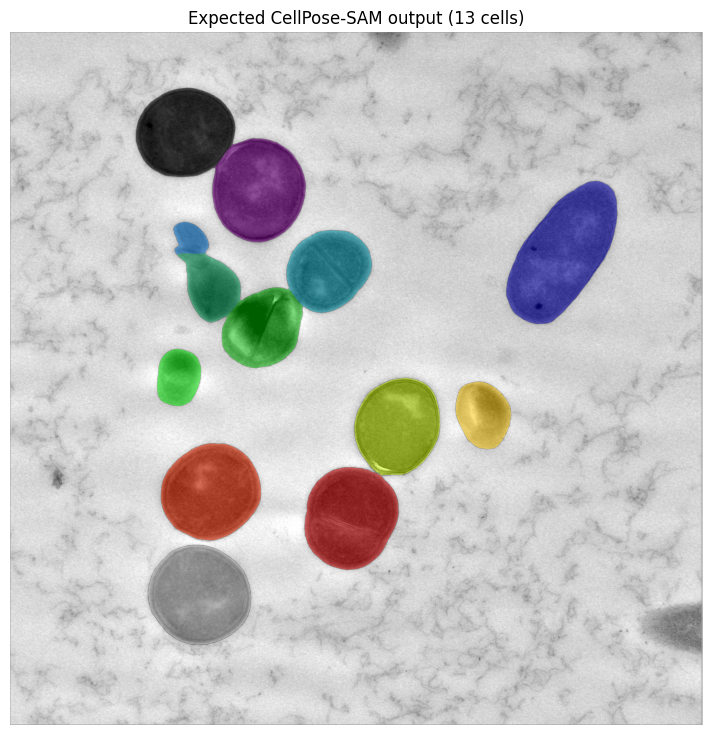

In [2]:
masks_expected = np.load("example_high_res_labels_expected.npz")["labels"]

plt.figure(figsize=(9, 9))
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.imshow(np.ma.masked_where(masks_expected == 0, masks_expected), cmap="nipy_spectral", alpha=0.5)
plt.title(f"Expected CellPose-SAM output ({masks_expected.max()} cells)")
plt.axis("off")
plt.show()

# use the live result if the cell above was uncommented and run, otherwise fall back
# to the precomputed reference -- everything below just uses 'masks'
masks = masks_live if "masks_live" in dir() else masks_expected

## Step 2: Classification: rod vs. ball (DINOv2 features + logistic regression)

The trained DINOv2 model is used to extract features from the detected bacteria. Each cell's crop is pooled into a 384-number descriptor, and a simple logistic regression (trained separately on 88 hand-labeled cells, saved as `dino_logreg_classifier.joblib`) is actually fit to this project's data. 

In [3]:
import torch
import torch.nn.functional as F
from skimage.measure import regionprops


dino = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14_reg", source="github")
dino.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
dino = dino.to(device)

PATCH = 14
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
PAD = 20  # crop padding around each cell's bounding box, in pixels


def extract_dino_features(gray_crop, mask_crop):
    """Per-cell 384-dim DINOv2 feature vector, pooled over the cell's own mask."""
    x = np.stack([gray_crop, gray_crop, gray_crop], axis=0).astype(np.float32)
    xt = torch.from_numpy(x)
    xt = (xt - IMAGENET_MEAN) / IMAGENET_STD

    h, w = xt.shape[-2:]
    pad_h = (PATCH - h % PATCH) % PATCH
    pad_w = (PATCH - w % PATCH) % PATCH
    xt = F.pad(xt, (0, pad_w, 0, pad_h), mode="reflect")
    xt = xt.unsqueeze(0).to(device)

    with torch.no_grad():
        patch_tokens = dino.forward_features(xt)["x_norm_patchtokens"]

    n_channels = patch_tokens.shape[-1]
    grid_h, grid_w = xt.shape[-2] // PATCH, xt.shape[-1] // PATCH
    feat_map = patch_tokens.reshape(1, grid_h, grid_w, n_channels).permute(0, 3, 1, 2)
    feat_map = F.interpolate(feat_map, size=(xt.shape[-2], xt.shape[-1]),
                              mode="bilinear", align_corners=False)
    feat_map = feat_map[0, :, :h, :w].cpu().numpy()

    return feat_map[:, mask_crop].mean(axis=1)


gray_float = img.mean(axis=-1).astype(np.float32) / 255.0
features, cell_ids = [], []
for prop in regionprops(masks):
    r0, c0, r1, c1 = prop.bbox
    r0p, c0p = max(0, r0 - PAD), max(0, c0 - PAD)
    r1p, c1p = min(masks.shape[0], r1 + PAD), min(masks.shape[1], c1 + PAD)
    crop = gray_float[r0p:r1p, c0p:c1p]
    mask_crop = masks[r0p:r1p, c0p:c1p] == prop.label

    features.append(extract_dino_features(crop, mask_crop))
    cell_ids.append(prop.label)

features = np.stack(features)
print(f"extracted features for {len(cell_ids)} cells, shape={features.shape}")

Using cache found in /home/nv277/.cache/torch/hub/facebookresearch_dinov2_main
/home/nv277/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/nv277/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/nv277/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


extracted features for 13 cells, shape=(13, 384)


In [4]:
import joblib

clf = joblib.load("dino_logreg_classifier.joblib")
predictions = clf.predict(features)

records = [dict(label=cid, shape=pred) for cid, pred in zip(cell_ids, predictions)]
for r in records:
    print(r)

{'label': 1, 'shape': 'ball'}
{'label': 2, 'shape': 'ball'}
{'label': 3, 'shape': 'rod'}
{'label': 4, 'shape': 'ball'}
{'label': 5, 'shape': 'ball'}
{'label': 6, 'shape': 'ball'}
{'label': 7, 'shape': 'ball'}
{'label': 8, 'shape': 'ball'}
{'label': 9, 'shape': 'ball'}
{'label': 10, 'shape': 'ball'}
{'label': 11, 'shape': 'ball'}
{'label': 12, 'shape': 'ball'}
{'label': 13, 'shape': 'ball'}


/home/nv277/.conda/envs/cellpose/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/nv277/.conda/envs/cellpose/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/nv277/.conda/envs/cellpose/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.6.

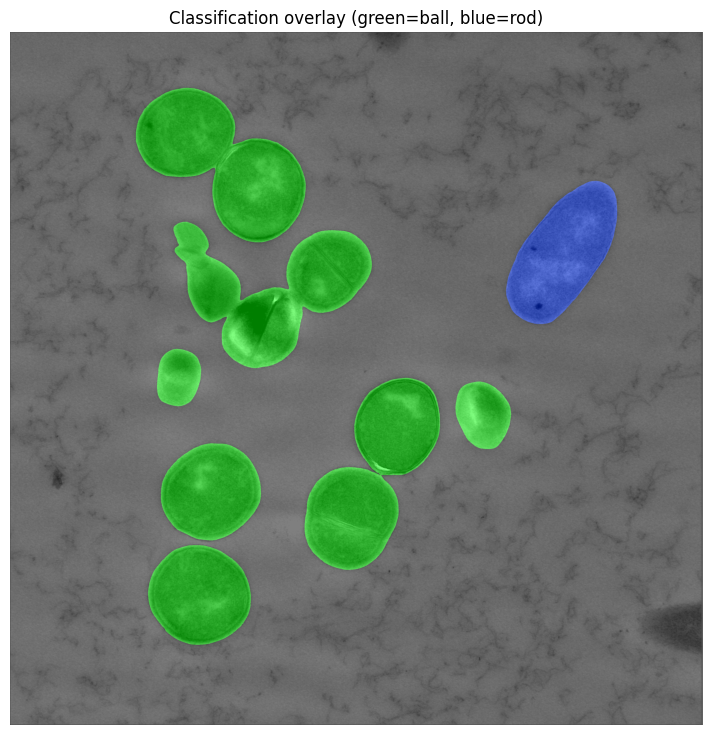

In [5]:
COLOR = {"ball": (0.0, 1.0, 0.0), "rod": (0.0, 0.2, 1.0)}

overlay = np.zeros((*masks.shape, 3))
for r in records:
    color = COLOR[r["shape"]]
    for c in range(3):
        overlay[:, :, c] += (masks == r["label"]) * color[c]

plt.figure(figsize=(9, 9))
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.imshow(overlay, alpha=0.5)
plt.title("Classification overlay (green=ball, blue=rod)")
plt.axis("off")
plt.show()

In [6]:
import pandas as pd
from collections import Counter

counts = Counter(r["shape"] for r in records)
summary = pd.DataFrame({"detection": list(counts.keys()), "number": list(counts.values())})
summary

,detection,number
0,ball,12
1,rod,1


### Amended labels (after human correction)

The automated classifier above only knows rod/ball, so it forces every detection into one of those two -- including the debris and dividing cells in this image. Below is the actual amended result for this same image, produced with the napari-based correction tool described in the main text (available upon request), which supports six categories: rod, ball, debris, dividing-rod, dividing-ball, dead-ball. This is loaded here for comparison, not re-derived -- the correction tool itself is not part of this notebook.

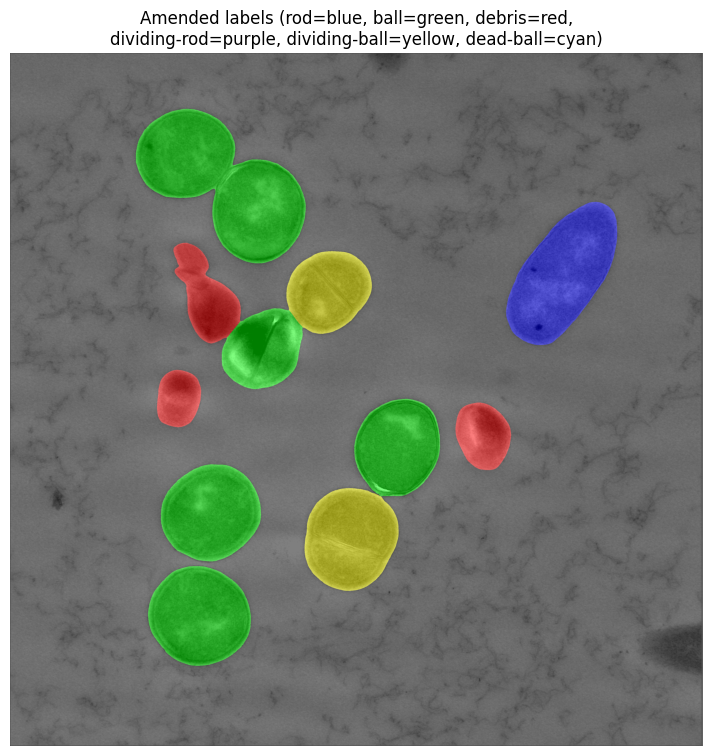

In [7]:
import csv

CATEGORY_COLORS = {
    "rod": (0.0, 0.0, 1.0),
    "ball": (0.0, 1.0, 0.0),
    "debris": (1.0, 0.0, 0.0),
    "dividing-rod": (0.6, 0.0, 1.0),
    "dividing-ball": (1.0, 1.0, 0.0),
    "dead-ball": (0.0, 1.0, 1.0),
}

masks_amended = np.load("example_high_res_labels_amended.npz")["labels"]
with open("example_high_res_amended_classifications.csv") as f:
    amended_records = [dict(label=int(r["cell_id"]), shape=r["classification"])
                        for r in csv.DictReader(f)]

overlay_amended = np.zeros((*masks_amended.shape, 3))
for r in amended_records:
    color = CATEGORY_COLORS[r["shape"]]
    for c in range(3):
        overlay_amended[:, :, c] += (masks_amended == r["label"]) * color[c]

plt.figure(figsize=(9, 9))
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.imshow(overlay_amended, alpha=0.5)
plt.title("Amended labels (rod=blue, ball=green, debris=red,\ndividing-rod=purple, dividing-ball=yellow, dead-ball=cyan)")
plt.axis("off")
plt.show()

In [8]:
amended_counts = Counter(r["shape"] for r in amended_records)
amended_summary = pd.DataFrame({"detection": list(amended_counts.keys()),
                                 "number": list(amended_counts.values())})
amended_summary

,detection,number
0,ball,6
1,rod,1
2,debris,4
3,dividing-ball,2
